# X-n115-k10.vrp
Analysis of nsga-ii and weighted-sum methods after 10min.

Settings: 
- capacity: diesel is unchanged, clean is 90% of provided capacity
- termination: 10min = 600s
- fleet number: 20 - 10 clean, 10 diesel

In [26]:
import matplotlib.pyplot as plt
import os
def plot_fronts(weighted_front, median_front, legend=True, path_save=None):
    xs = [p[0] for p in weighted_front]
    ys = [p[1] for p in weighted_front]

    nsga_x = [p[0] for p in median_front]
    nsga_y = [p[1] for p in median_front]

    plt.scatter(xs, ys, color="green", label="Weighted-sum front")
    plt.scatter(nsga_x, nsga_y, color="blue", label="Median NSGA-II front")

    plt.xlabel("Total distance")
    plt.ylabel("CO$_2$ emissions")
    plt.title("Distance vs CO$_2$ for instance X-n115-k10.vrp")
    plt.grid(True, alpha=0.3)
    if legend:
        plt.legend()

    if path_save:
        directory = os.path.dirname(path_save)

        if directory and not os.path.exists(directory):
            os.makedirs(directory)
            print(f"Created directory: {directory}")
        
        plt.savefig(path_save, dpi=1000)

    plt.show()

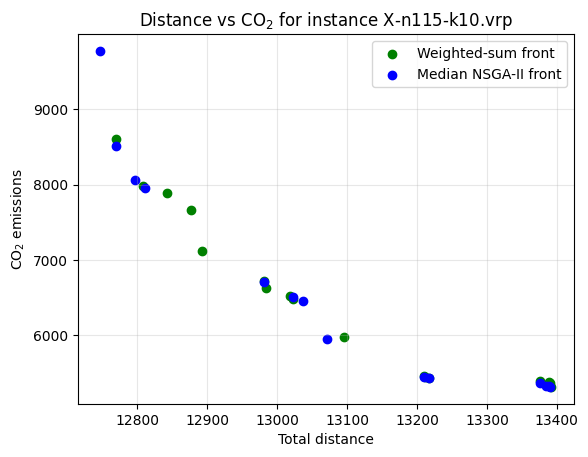

In [27]:
nsga2_10min = [(12747.0, 9772.938840277951),
(12769.0, 8516.662747928603),
(12796.0, 8059.720183108067),
(12811.0, 7960.118187115385),
(12981.0, 6706.504375236295),
(13022.0, 6504.896763453358),
(13037.0, 6455.920987957798),
(13071.0, 5952.157716147619),
(13210.0, 5447.632418117798),
(13217.0, 5435.818493512536),
(13376.0, 5362.811929227656),
(13385.0, 5324.539372049206),
(13389.0, 5321.800778036049),
(13390.0, 5315.950377180785)]


weighted_sum_10min = [(12769.00, 8603.91),
(12808.00, 7975.32),
(12843.00, 7892.93),
(12876.00, 7659.93),
(12892.00, 7114.92),
(12981.00, 6727.44),
(12984.00, 6629.39),
(13019.00, 6526.78),
(13023.00, 6484.55),
(13095.00, 5983.50),
(13210.00, 5467.21),
(13212.00, 5452.89),
(13217.00, 5436.74),
(13376.00, 5388.79),
(13389.00, 5378.27),
(13390.00, 5372.34),
(13392.00, 5318.03)]
plot_fronts(weighted_sum_10min, nsga2_10min, path_save="images/fig1.png")

## Computation of hypervolume

In [28]:
def ref_point(list_fronts):
    max_dist = max(p[0] for front in list_fronts for p in front)
    max_co2 = max(p[1] for front in list_fronts for p in front)
    return (max_dist * 1.05, max_co2 * 1.05)

def hypervolume(front, ref_pt):
    sorted_front = sorted(front, key=lambda p: p[0])
    hv = 0.0
    prev_y = ref_pt[1]

    for dist, co2 in sorted_front:
        width = ref_pt[0] - dist
        height = prev_y - co2
        hv += width * height
        prev_y = co2

    return hv

In [29]:
h_nsga2 = hypervolume(nsga2_10min, ref_point([nsga2_10min]))
h_ws = hypervolume(weighted_sum_10min, ref_point([weighted_sum_10min]))
h_nsga2, h_ws
#ref_point([nsga2_10min]), ref_point([weighted_sum_10min])

(5593526.918502919, 4063463.8013000013)